bordes

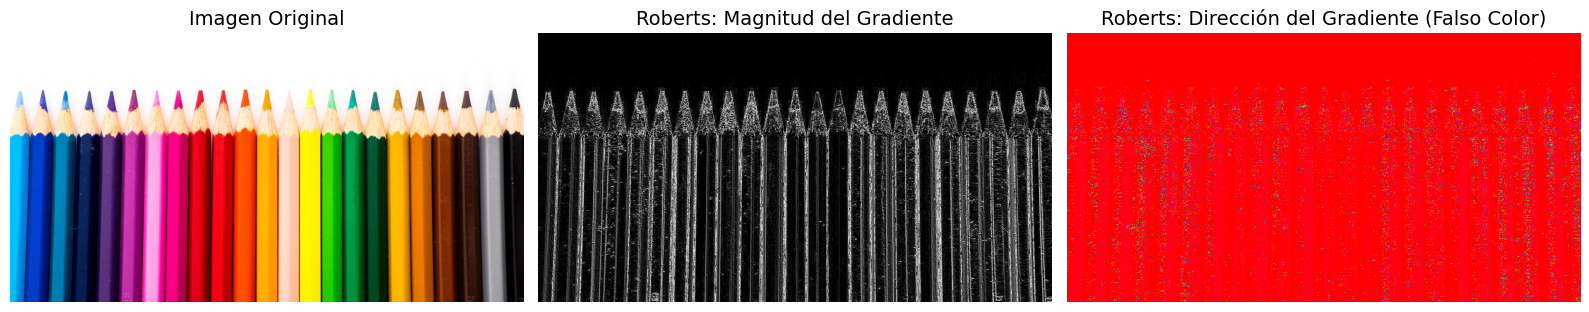

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- BLOQUE 1: CARGA DE IMAGEN (TU RUTA EXACTA) ---
# Usamos raw string (r'') para evitar problemas con las barras invertidas
ruta_imagen = r'D:\UNIVALLE\PDY\unidad 1\clases\img\colores.jpg'
img = cv2.imread(ruta_imagen)

# Verificación de seguridad para asegurar que la imagen se cargó
if img is None:
    print(f"Error: No se pudo cargar la imagen. Revisa la ruta: {ruta_imagen}")
else:
    # --- BLOQUE 2: PROCESAMIENTO (TU CÓDIGO ORIGINAL) ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Definición de los kernels de Roberts
    robertx = np.array([[-1, 0], [0, 1]])
    roberty = np.array([[0, -1], [1, 0]])

    # Aplicación de los filtros (convolución)
    robx_img = cv2.filter2D(gray, -1, robertx)
    roby_img = cv2.filter2D(gray, -1, roberty)

    # Cálculo de la magnitud y dirección del gradiente
    rob_grad = np.sqrt(robx_img**2 + roby_img**2)
    rob_grad_dir = np.arctan2(roby_img, robx_img)

    # --- BLOQUE 3: PLOTEO (VISUALIZACIÓN ESTILO SOBEL) ---
    # Convertimos la imagen original de BGR (OpenCV) a RGB (Matplotlib) para que los colores sean correctos
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Configuramos la ventana de ploteo
    plt.figure(figsize=(16, 8)) # Ventana más ancha para mostrar 3 imágenes

    # 1. Imagen Original
    plt.subplot(1, 3, 1) # 1 fila, 3 columnas, posición 1
    plt.title("Imagen Original", fontsize=14)
    plt.imshow(img_rgb)
    plt.axis('off') # Ocultar los ejes

    # 2. Magnitud del Gradiente (Resultado principal del filtro de bordes)
    plt.subplot(1, 3, 2) # Posición 2
    plt.title("Roberts: Magnitud del Gradiente", fontsize=14)
    # Es crucial usar cmap='gray' para ver el resultado de bordes correctamente
    plt.imshow(rob_grad, cmap='gray') 
    plt.axis('off')

    # 3. Dirección del Gradiente (Opcional, pero interesante de ver)
    plt.subplot(1, 3, 3) # Posición 3
    plt.title("Roberts: Dirección del Gradiente (Falso Color)", fontsize=14)
    # La dirección a menudo se plotea con mapas de colores cíclicos como 'hsv' o 'twilight'
    plt.imshow(rob_grad_dir, cmap='hsv')
    plt.axis('off')

    # Ajustar el diseño para que no se superpongan los títulos
    plt.tight_layout()
    
    # Mostrar la ventana con las imágenes
    plt.show()

prewit 

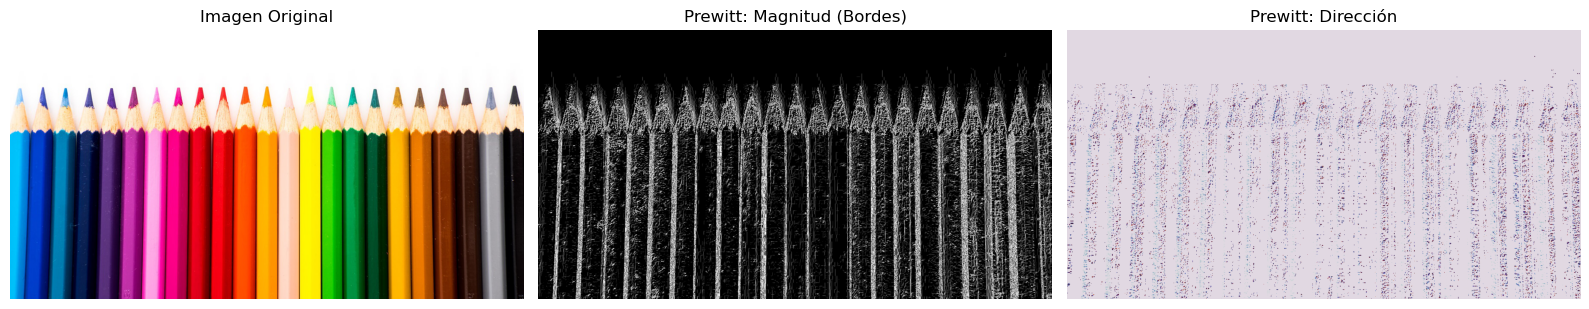

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- 1. CARGA DE IMAGEN (TU RUTA) ---
ruta_imagen = r'D:\UNIVALLE\PDY\unidad 1\clases\img\colores.jpg'
img = cv2.imread(ruta_imagen)

if img is None:
    print(f"No se encontró la imagen en: {ruta_imagen}")
else:
    # --- 2. PREPROCESAMIENTO ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # --- 3. PROCESAMIENTO PREWITT (TU CÓDIGO) ---
    prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    prewitt_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])

    prex_img = cv2.filter2D(gray, -1, prewitt_x)
    prey_img = cv2.filter2D(gray, -1, prewitt_y)

    # Nota: Se corrigió **1 por **2 para obtener la magnitud real
    prewitt_mag = np.sqrt(prex_img**2 + prey_img**2)
    preww_dir = np.arctan2(prey_img, prex_img)

    # --- 4. PLOTEO DE RESULTADOS ---
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(16, 8))

    # Imagen Original
    plt.subplot(1, 3, 1)
    plt.title("Imagen Original")
    plt.imshow(img_rgb)
    plt.axis('off')

    # Magnitud de Prewitt (Bordes detectados)
    plt.subplot(1, 3, 2)
    plt.title("Prewitt: Magnitud (Bordes)")
    plt.imshow(prewitt_mag, cmap='gray')
    plt.axis('off')

    # Dirección del Gradiente
    plt.subplot(1, 3, 3)
    plt.title("Prewitt: Dirección")
    plt.imshow(preww_dir, cmap='twilight')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

solbetl

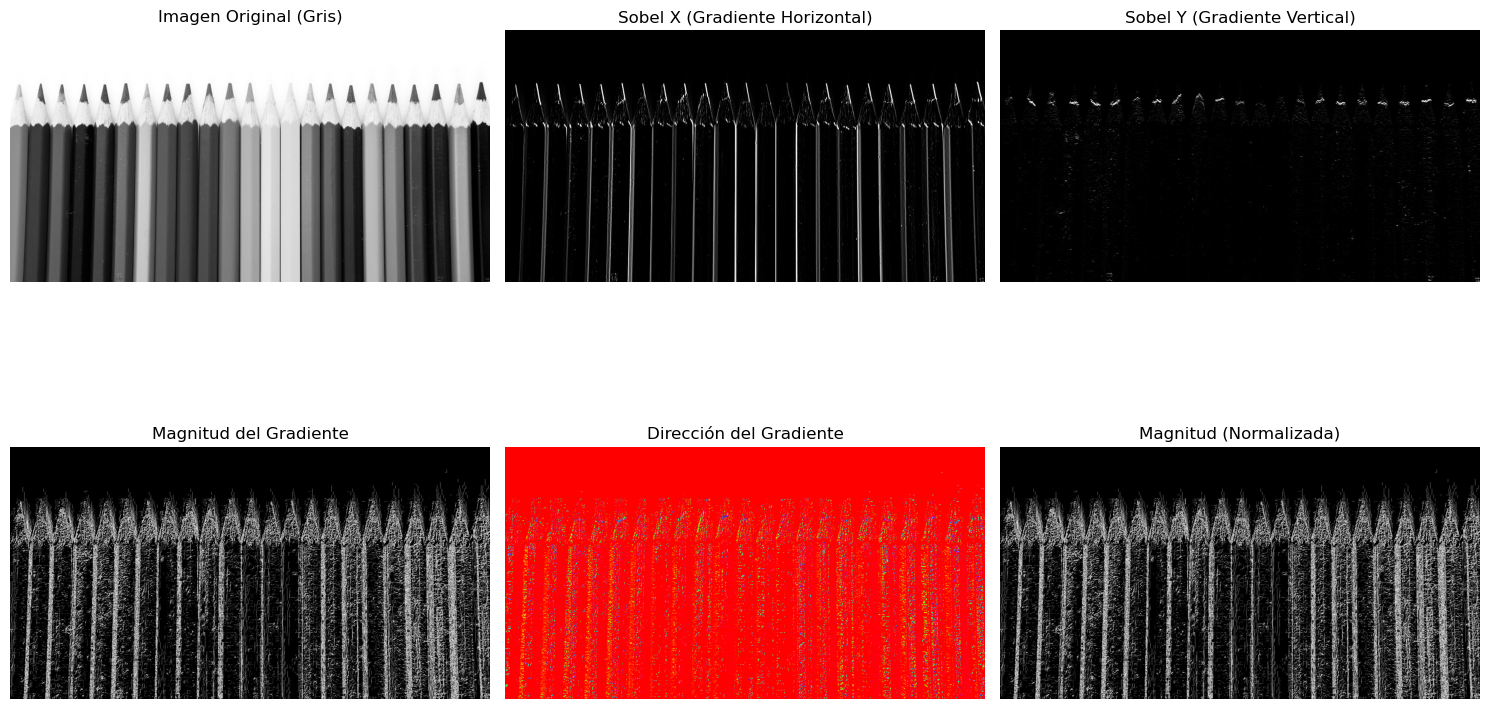

Magnitud - Min: 0.00, Max: 15.81, Mean: 2.82
Dirección - Rango: [0.00, 1.57] radianes


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Tu código original
sobel_x = np.array([[-1,0,1],[-2,0,2],[-1,0,1]])
sobel_y = np.array([[-1,-2,-1],[0,0,0],[1,2,1]])

sobelx_img = cv2.filter2D(gray, -1, sobel_x)
sobely_img = cv2.filter2D(gray, -1, sobel_y)

# Nota: CORRECCIÓN - Debería ser cuadrado, no multiplicado por 2
sobel_mag = np.sqrt(sobelx_img**2 + sobely_img**2)
sobel_dir = np.arctan2(sobely_img, sobelx_img)

# Visualización
plt.figure(figsize=(15, 10))

# Imagen original en escala de grises
plt.subplot(2, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Imagen Original (Gris)')
plt.axis('off')

# Gradiente en X
plt.subplot(2, 3, 2)
plt.imshow(sobelx_img, cmap='gray')
plt.title('Sobel X (Gradiente Horizontal)')
plt.axis('off')

# Gradiente en Y
plt.subplot(2, 3, 3)
plt.imshow(sobely_img, cmap='gray')
plt.title('Sobel Y (Gradiente Vertical)')
plt.axis('off')

# Magnitud del gradiente
plt.subplot(2, 3, 4)
plt.imshow(sobel_mag, cmap='gray')
plt.title('Magnitud del Gradiente')
plt.axis('off')

# Dirección del gradiente
plt.subplot(2, 3, 5)
plt.imshow(sobel_dir, cmap='hsv')
plt.title('Dirección del Gradiente')
plt.axis('off')

# Magnitud normalizada para mejor visualización
plt.subplot(2, 3, 6)
plt.imshow(sobel_mag / sobel_mag.max(), cmap='gray')
plt.title('Magnitud (Normalizada)')
plt.axis('off')

plt.tight_layout()
plt.show()

# Información estadística
print(f"Magnitud - Min: {sobel_mag.min():.2f}, Max: {sobel_mag.max():.2f}, Mean: {sobel_mag.mean():.2f}")
print(f"Dirección - Rango: [{sobel_dir.min():.2f}, {sobel_dir.max():.2f}] radianes")

# Canny

solbel

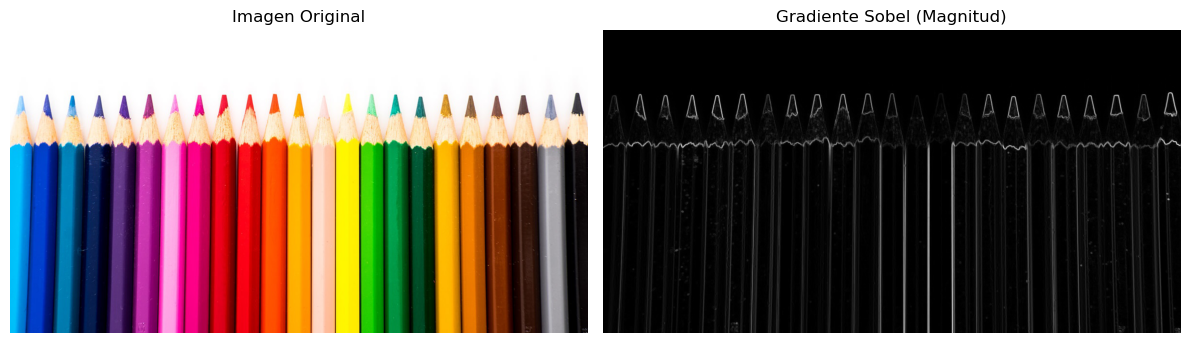

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img):
    img_gris=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    
    g_x=cv2.Sobel(img_gris,cv2.CV_64F,1,0,ksize=3)
    g_y=cv2.Sobel(img_gris,cv2.CV_64F,0,1,ksize=3)
    
    mag=np.sqrt(np.square(g_x)+np.square(g_y))
    mag=cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX,cv2.CV_8U)
    return mag

# Carga de la imagen usando tu ruta específica
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\colores.jpg'
imagen_original = cv2.imread(ruta)

if imagen_original is not None:
    # Aplicar el filtro
    resultado_sobel = filtro_sobel(imagen_original)

    # Convertir de BGR a RGB para mostrar correctamente con matplotlib
    img_rgb = cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB)

    # Ploteo de los resultados
    plt.figure(figsize=(12, 6))

    # Imagen Original
    plt.subplot(1, 2, 1)
    plt.title("Imagen Original")
    plt.imshow(img_rgb)
    plt.axis('off')

    # Imagen con Filtro Sobel
    plt.subplot(1, 2, 2)
    plt.title("Gradiente Sobel (Magnitud)")
    plt.imshow(resultado_sobel, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No se pudo encontrar la imagen en la ruta especificada.")

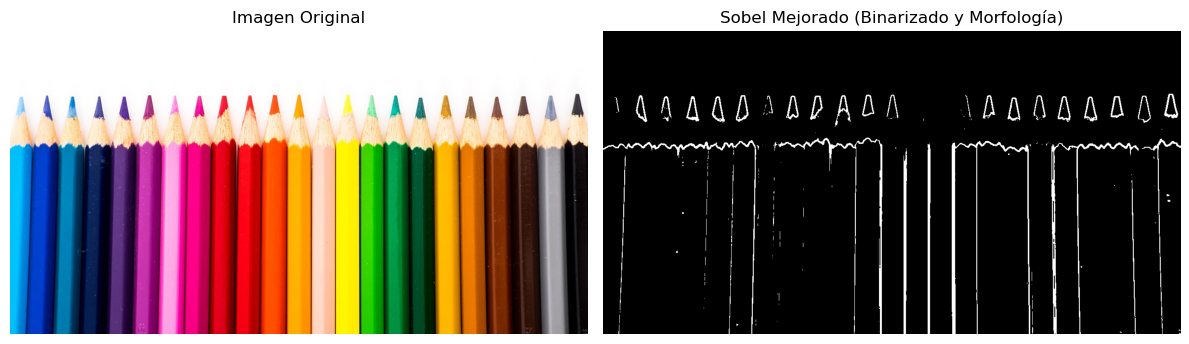

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel_mejorado(img, kernel_size=3, umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # para mejorar la deteccion filtro gauss
    img_gris = cv2.GaussianBlur(img_gris, (3, 3), 0)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=kernel_size)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=kernel_size)

    # mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag = np.sqrt(g_x**2 + g_y**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    
    _, bordes = cv2.threshold(mag, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    # OPERACION MORPH UNIR BORDES ROTOS
    kernel_m = np.ones((2, 2), np.uint8)
    bordes = cv2.morphologyEx(bordes, cv2.MORPH_CLOSE, kernel_m)
    
    return bordes

# --- Código para mostrar la imagen ---
ruta = r'D:\UNIVALLE\PDY\unidad 1\clases\img\colores.jpg'
imagen_original = cv2.imread(ruta)

if imagen_original is not None:
    resultado = filtro_sobel_mejorado(imagen_original)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("Imagen Original")
    plt.imshow(cv2.cvtColor(imagen_original, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Sobel Mejorado (Binarizado y Morfología)")
    plt.imshow(resultado, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No se pudo cargar la imagen.")

robert

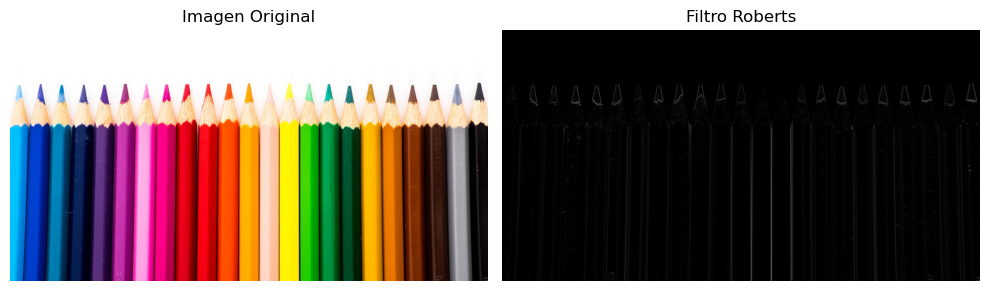

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_roberts(img):
    # Convertir a escala de grises
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Kernels de Roberts
    robertx = np.array([[-1, 0],
                        [0, 1]], dtype=np.float32)

    roberty = np.array([[0, -1],
                        [1, 0]], dtype=np.float32)

    # Aplicar convolución
    r_x = cv2.filter2D(img_gris, -1, robertx)
    r_y = cv2.filter2D(img_gris, -1, roberty)

    # Combinar resultados
    roberts = cv2.addWeighted(r_x, 0.5, r_y, 0.5, 0)

    return roberts

# 📌 Tu ruta
ruta_imagen = r'D:\UNIVALLE\PDY\unidad 1\clases\img\colores.jpg'
img = cv2.imread(ruta_imagen)

# ⚠️ Verificación (MUY IMPORTANTE)
if img is None:
    print("Error: No se pudo cargar la imagen. Verifica la ruta.")
else:
    # Aplicar filtro
    img_roberts = filtro_roberts(img)

    # Mostrar comparación
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.title("Imagen Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title("Filtro Roberts")
    plt.imshow(img_roberts, cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()